In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [4]:
from simulators import NestedModelFamily
from simulators.benchmarks import DDM

### Priors

In [3]:
ddm_priors = {
    "v":     {"intercept": lambda: np.random.gamma(2.0, 0.8),
              "slope":     lambda: 0.0},
    "a":     {"intercept": lambda: np.random.gamma(10.0, 0.3),
              "slope":     lambda: 0.0},
    "tau":   {"intercept": lambda: np.random.gamma(3.0, 0.2),
              "slope":     lambda: 0.0},
    "s_v":   {"intercept": lambda: np.random.gamma(1.0, 0.2),
              "slope":     lambda: 0.0},
    "s_tau": {"intercept": lambda: np.random.uniform(0.0, 0.4),
              "slope":     lambda: 0.0},
    "decay": {"intercept": lambda: np.random.gamma(1.0, 0.4),
              "slope":     lambda: 0.0},
}

In [5]:
ddm_family = NestedModelFamily(name="ddm", model=DDM(), prior_fun=ddm_priors)

In [7]:
ddm_samples = ddm_family.batch_sample(
    batch_size=8,
    mask_randomizer_kwargs=dict(
        free_intrinsics={"v", "a", "tau", "s_v", "decay"},
        fixed_intrinsics={"s_tau"}
    ),
    num_obs=200,
    flatten_param_outputs=True
)

In [10]:
for k, v in ddm_samples["sim_data"].items():
    print(k, v.shape)

rts (8, 200, 1)
choices (8, 200, 1)


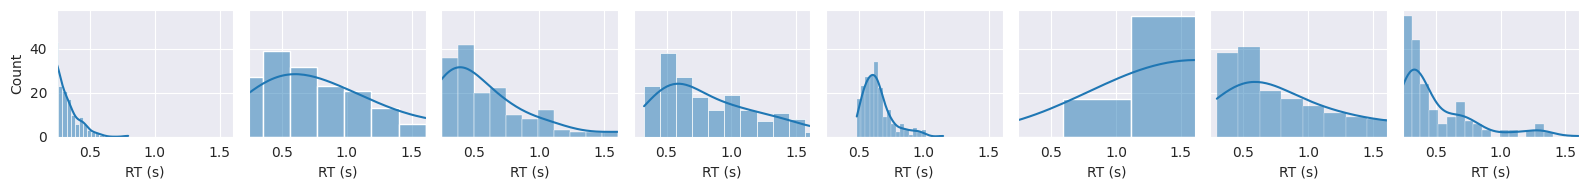

In [39]:
rts = ddm_samples["sim_data"]["rts"]

f, axarr = plt.subplots(1, 8, figsize=(16, 2), sharex=True, sharey=True)
for i, ax in enumerate(axarr.flat):
    sns.histplot(rts[i], ax=ax, kde=True, legend=False, bins=20)
    ax.set_xlabel("RT (s)")
    x_min, x_max = np.min(rts[i]), np.max(rts[i])
    axarr[i].set_xlim(x_min, x_max)

f.tight_layout()

In [37]:
np.max(rts[6])

np.float64(9.596063613891602)